In [1]:
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

import numpy as np
import matplotlib.pyplot as plt
import orcs.process
import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt

import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

from astropy.convolution import convolve, Gaussian2DKernel
from astropy.convolution import interpolate_replace_nans

In [2]:
from scipy.ndimage import median_filter, gaussian_filter
flux = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits') 
err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')


In [3]:
# Calzetti et al. (2000) attenuation curve

Rv = 4.05

# Wavelengths in microns
lambda_Halpha = 6563 / 10000   
lambda_Hbeta  = 4861 / 10000 


# Hbeta: 0.12 < lambda < 0.63 μm
k_hbeta = (2.659 *(-2.156 + (1.509 / lambda_Hbeta) - (0.198 / (lambda_Hbeta**2)) + (0.011 / (lambda_Hbeta**3)))+ Rv)


# Halpha: 0.63 < lambda < 2.20 μm
k_halpha = (2.659 *(-1.857 + (1.040 / lambda_Halpha)) + Rv)


print("k(Halpha) =", k_halpha)
print("k(Hbeta)  =", k_hbeta)

k(Halpha) = 3.325797871552644
k(Hbeta)  = 4.598085137101848


unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False
unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_12234/1597291906.py:48: RuntimeWarning: invalid value encountered in divide
  hb_line_snr = map_hb / map_hb_err



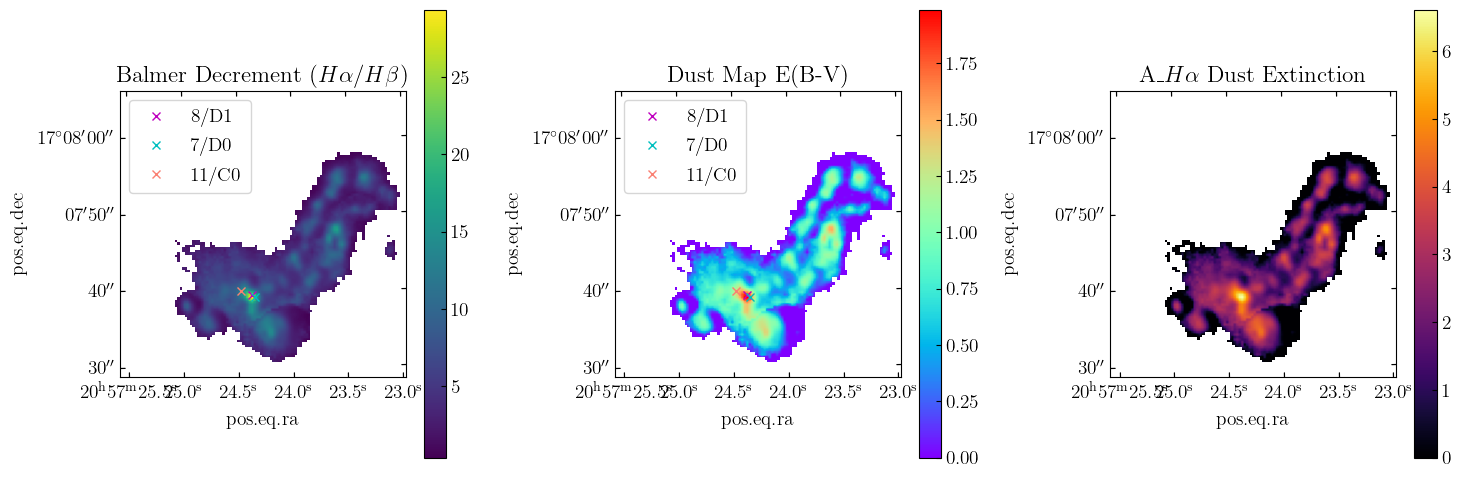

In [4]:
from astropy.io import fits
import numpy as np
import astropy.io.fits as fits
from reproject import reproject_interp
import orb
import orb.utils.graph as graph
import matplotlib.pyplot as plt
from orcs.process import SpectralCube
from astropy.coordinates import SkyCoord
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18
from scipy.ndimage import generic_filter
from astropy.convolution import convolve, Gaussian2DKernel

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
# Recommended for any plot for a science publication.
# Some paper submision systems (e.g. MNRAS) requires next lines to be done for
# your pictures.
# Read more about font types: https://en.wikipedia.org/wiki/PostScript_fonts
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.fonttype'] = 42
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight']= 'normal'

# to be changed depending on where you save IIZw96 data
data_path = '/Users/leianydeoleo/Desktop/IIZw96/'

cube_SN3 = SpectralCube(data_path + 'SN3.hdf5')

map_ha = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')
ha_line_snr = map_ha / map_ha_err
#valid_mask = (ha_line_snr > 3) & np.isfinite(map_ha)
#map_ha[~valid_mask] = np.nan
map_ha[map_ha<0] = np.nan
map_ha[ha_line_snr<=3] = np.nan




map_hb =  flux
map_hb_err = err
hb_line_snr = map_hb / map_hb_err
#valid_mask_hb = (hb_line_snr > 3) & np.isfinite(map_hb)
#map_hb[~valid_mask_hb] = np.nan
map_hb[map_hb<0] = np.nan
map_hb[hb_line_snr<=3] = np.nan

kernel = Gaussian2DKernel(x_stddev=1.2)


map_hb = convolve(map_hb, kernel, nan_treatment='interpolate', preserve_nan=False)


position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')



def compute_dust_maps():

    # Balmer decrement
    balmer = map_ha / map_hb
    balmer[balmer <= 0] = np.nan

    intrinsic = 2.86

    # Color excess
    kHa = k_halpha
    kHb = k_hbeta

    EBV = (1.086/(kHb - kHa)) * np.log(balmer / intrinsic)

    EBV[EBV < 0] = 0

    # Extinction maps
    Av = Rv * EBV 
    Aha = kHa * EBV  

    
    # --------------------------
    # Plot maps
    # --------------------------
    fig = plt.figure(figsize=(15,5))

    ax1 = fig.add_subplot(131, projection=cube_SN3.get_wcs())
    im1 = ax1.imshow(balmer.T, origin='lower',
                     cmap='viridis',
                     vmin=np.nanpercentile(balmer,0),
                     vmax=np.nanpercentile(balmer,100))
    # Region ID8/D1
    ax1.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax1.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax1.plot_coord(position_ID11, "x", c='salmon', label='11/C0')
    ax1.legend(loc='upper left')
    ax1.set_title(r"Balmer Decrement ($H\alpha/H\beta$)")
    ax1.set_xlim(1000,1115)
    ax1.set_ylim(1000,1115)
    plt.colorbar(im1, ax=ax1)

    ax2 = fig.add_subplot(132, projection=cube_SN3.get_wcs())
    im2 = ax2.imshow(EBV.T, origin='lower',
        cmap='rainbow',
        vmin=np.nanpercentile(EBV,0), vmax=np.nanpercentile(EBV,100)
)
    # Region ID8/D1
    ax2.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax2.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax2.plot_coord(position_ID11, "x", c='salmon', label='11/C0')
    ax2.legend(loc='upper left')
    ax2.set_title("Dust Map E(B-V)")
    ax2.set_xlim(1000,1115)
    ax2.set_ylim(1000,1115)
    plt.colorbar(im2, ax=ax2)

    ax3 = fig.add_subplot(133, projection=cube_SN3.get_wcs())
    im3 = ax3.imshow(Aha.T, origin='lower',
                     cmap='inferno',
                     vmin=np.nanpercentile(Aha,0),
                     vmax=np.nanpercentile(Aha,100))
    ax3.set_title(r"A_$H\alpha$ Dust Extinction")
    ax3.set_xlim(1000,1115)
    ax3.set_ylim(1000,1115)
    plt.colorbar(im3, ax=ax3)
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_balmer_extinc_dust.pdf")

    
    plt.tight_layout()
    plt.show()

    return EBV, Av, balmer
EBV, Av, balmer = compute_dust_maps()

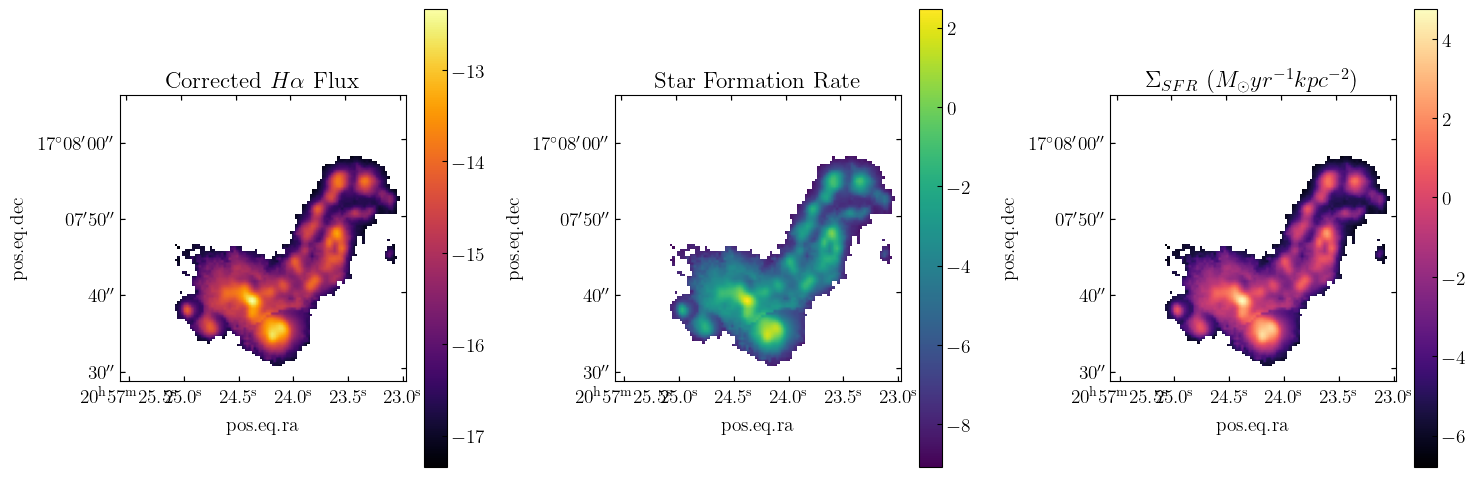

PLOTTING:
log Halpha: -17.34430753710358 -12.330985907377121
log SFR: -9.071832191963724 2.471767459029042
log Sigma: -6.792963625586995 4.750636025405772


In [5]:
def compute_sfr_maps():

    kHa = k_halpha


    # Correct Hα flux for extinction Calzetti et al 2000
    Aha = kHa * EBV
    #EsBV = 0.44 * EBV
    
    ha_corr = map_ha * 10**(0.4 * Aha) #halpha flux corrected map 
    ha_corr[ha_corr <= 0] = np.nan

    # Flux / Luminosity
    cosmo = Planck18
    redshift = 0.036  # IIZw96
    DL = cosmo.luminosity_distance(redshift).to(u.cm).value
    
    #corrected luminosity 
    Lha = 4 * np.pi * (DL**2) * ha_corr

 
    # Luminosity / SFR
    # Kennicutt(1998) relation
    SFR = 7.9e-42 * Lha
    SFR[SFR <= 0] = np.nan

     # SFR Surface Density
    pixel_size_kpc =0.32
    pixel_area_kpc2 = pixel_size_kpc**2

    Sigma_SFR = SFR / pixel_area_kpc2

    
    # Plot maps
    fig = plt.figure(figsize=(15,5))

    # Hα corrected flux
    ax1 = fig.add_subplot(131, projection=cube_SN3.get_wcs())
    im1 = ax1.imshow(np.log10(ha_corr.T), origin='lower',
                     cmap='inferno',
                     vmin=np.nanpercentile(np.log10(ha_corr.T),0),
                     vmax=np.nanpercentile(np.log10(ha_corr.T),100))
    ax1.set_title(r"Corrected $H\alpha$ Flux")
    ax1.set_xlim(1000,1115)
    ax1.set_ylim(1000,1115)
    plt.colorbar(im1, ax=ax1)

    # SFR map
    ax2 = fig.add_subplot(132, projection=cube_SN3.get_wcs())
    im2 = ax2.imshow(np.log(SFR.T), origin='lower',
                     cmap='viridis',
                     vmin=np.nanpercentile(np.log(SFR.T),0),
                     vmax=np.nanpercentile(np.log(SFR.T),100))
    ax2.set_title("Star Formation Rate")
    ax2.set_xlim(1000,1115)
    ax2.set_ylim(1000,1115)
    plt.colorbar(im2, ax=ax2)

    # SFR surface density
    ax3 = fig.add_subplot(133, projection=cube_SN3.get_wcs())
    im3 = ax3.imshow(np.log(Sigma_SFR.T), origin='lower',
                     cmap='magma',
                     vmin=np.nanpercentile(np.log(Sigma_SFR.T),0),
                     vmax=np.nanpercentile(np.log(Sigma_SFR.T),100))
    ax3.set_title(r"$\Sigma_{SFR}$ ($M_\odot yr^{-1} kpc^{-2}$)")
    ax3.set_xlim(1000,1115)
    ax3.set_ylim(1000,1115)
    plt.colorbar(im3, ax=ax3)
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_sfr.pdf")

    plt.tight_layout()
    plt.show()
    log_ha = np.log10(ha_corr)
    
    print("PLOTTING:")
    print("log Halpha:",
          np.nanmin(log_ha),
          np.nanmax(log_ha))
    
    print("log SFR:",
          np.nanmin(np.log(SFR)),
          np.nanmax(np.log(SFR)))
    
    print("log Sigma:",
          np.nanmin(np.log(Sigma_SFR)),
          np.nanmax(np.log(Sigma_SFR)))

    return SFR, Sigma_SFR, Lha

SFR, Sigma_SFR,Lha = compute_sfr_maps()

In [55]:

Aha = k_halpha * EBV
ha_corr = map_ha * 10**(0.4 * Aha)
print("map_ha:")
print("  min =", np.nanmin(map_ha))
print("  max =", np.nanmax(map_ha))

print("\nha_corr:")
print("  min =", np.nanmin(ha_corr))
print("  max =", np.nanmax(ha_corr))

print("\nLha:")
print("  min =", np.nanmin(Lha))
print("  max =", np.nanmax(Lha))

print("\nSFR:")
print("  min =", np.nanmin(SFR))
print("  max =", np.nanmax(SFR))

print("\nSigma_SFR:")
print("  min =", np.nanmin(Sigma_SFR))
print("  max =", np.nanmax(Sigma_SFR))

map_ha:
  min = 4.525769829073631e-18
  max = 8.360958884327634e-15

ha_corr:
  min = 5.214234320853048e-18
  max = 4.666745234064441e-13

Lha:
  min = 1.6750367043630155e+37
  max = 1.4991596226711682e+42

SFR:
  min = 0.00013232789964467823
  max = 11.843361019102227

Sigma_SFR:
  min = 0.001292264644967561
  max = 115.65782245217018


In [5]:

flux1 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.5007.1x1.flux.fits')
err1 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.5007.1x1.flux-err.fits')
finite = np.isfinite(flux1) & np.isfinite(err1)

# 2) Reject invalid error values
valid_err = err1 > 0

# 3) Local median of the flux map
local_med = median_filter(flux1, size=3, mode="nearest")

# 4) Robust local residual scale
resid = flux1 - local_med
resid_finite = resid[np.isfinite(resid)]
med_resid = np.nanmedian(resid_finite)
mad = np.nanmedian(np.abs(resid_finite - med_resid))
sigma = 1.4826 * mad

# 5) Bad-pixel mask
bad = (~finite) | (~valid_err) | (np.abs(resid - med_resid) > 5 * sigma)

# 6) Replace only bad pixels with local median
repaired = flux1.copy()
repaired[bad] = local_med[bad]

# 7) Very light smoothing
final1 = gaussian_filter(repaired, sigma=0.6)


flux = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits')
err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')
finite = np.isfinite(flux) & np.isfinite(err)

# 2) Reject invalid error values
valid_err = err > 0

# 3) Local median of the flux map
local_med = median_filter(flux, size=3, mode="nearest")

# 4) Robust local residual scale
resid = flux - local_med
resid_finite = resid[np.isfinite(resid)]
med_resid = np.nanmedian(resid_finite)
mad = np.nanmedian(np.abs(resid_finite - med_resid))
sigma = 1.4826 * mad

# 5) Bad-pixel mask
bad = (~finite) | (~valid_err) | (np.abs(resid - med_resid) > 5 * sigma)

# 6) Replace only bad pixels with local median
repaired = flux.copy()
repaired[bad] = local_med[bad]

# 7) Very light smoothing
final = gaussian_filter(repaired, sigma=0.5)

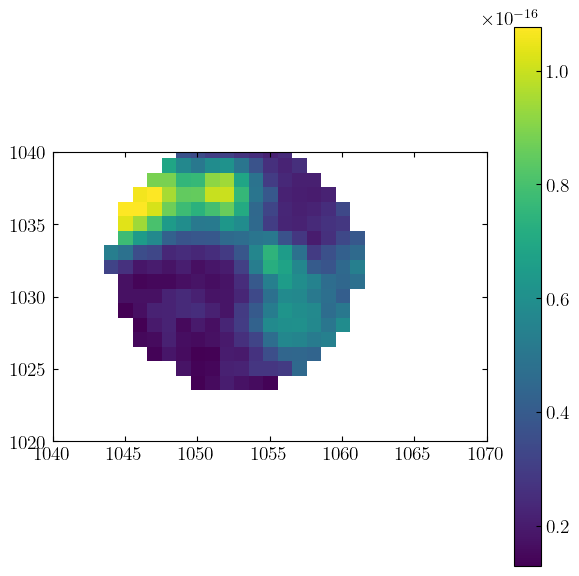

In [15]:
flux = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/BFiles/Aligned/MAPS_ID8_3arcsec/IIZw96_SN2.1.0.LineMaps.map.5007.1x1.flux_align.fits')
graph.imshow(flux)
pl.xlim(1040, 1070)
pl.ylim(1020, 1040)
pl.colorbar()

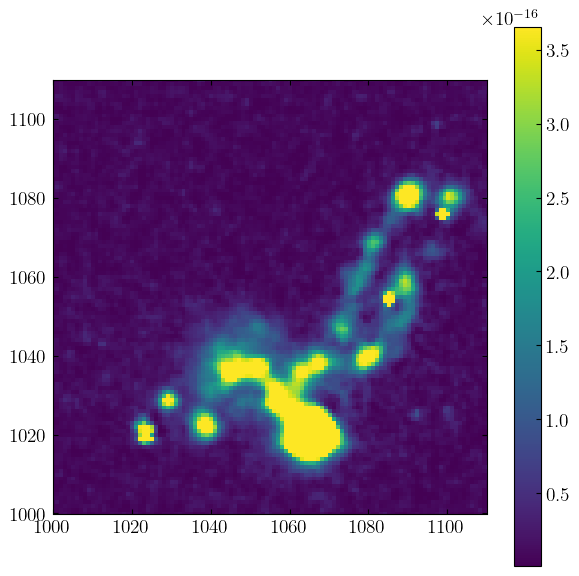

In [6]:
graph.imshow(final1)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()

In [9]:
position_ID1  = SkyCoord(314.350210, 17.126449, unit="deg")
position_ID2  = SkyCoord(314.350342, 17.126498, unit='deg')
position_ID3  = SkyCoord(314.350638, 17.126226, unit='deg')
position_ID4  = SkyCoord(314.351233, 17.127361, unit='deg')
position_ID5  = SkyCoord(314.351263, 17.127169, unit='deg')
position_ID6  = SkyCoord(314.351444, 17.127124, unit='deg')
position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID9  = SkyCoord(314.351688, 17.127728, unit='deg')
position_ID10 = SkyCoord(314.351945, 17.127588, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')
position_ID12 = SkyCoord(314.352156, 17.127821, unit='deg')
source_A = SkyCoord(314.350246, 17.126505, unit="deg")
source_B = SkyCoord(314.348473, 17.128958, unit="deg")
source_C = SkyCoord(314.352254, 17.127635, unit="deg")
source_D = SkyCoord(314.349750, 17.127639, unit="deg")

map_ha, map_ha_hdr = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits', return_header=True)
hdr = map_ha_hdr
wcs_sn3 = WCS(hdr)

map_hb_hdr =orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits', return_header=True)
hdrb = map_hb_hdr

wcs = WCS(map_ha_hdr)

x, y = position_ID8.to_pixel(wcs)

x = int(round(float(np.asarray(x).ravel()[0])))
y = int(round(float(np.asarray(y).ravel()[0])))

print("Pixel coordinates:", x, y)

ha  = map_ha[x,y]
hb  = map_hb[x,y]
nii = map_nii[x,y]
oiii = map_oiii[x,y]

print("Hα   =", ha)
print("Hβ   =", hb)
print("[NII] =", nii)
print("[OIII] =", oiii)

nii_ha = nii / ha
oiii_hb = oiii / hb

print("[NII]/Hα  =", nii_ha)
print("[OIII]/Hβ =", oiii_hb)

log_nii_ha_ID8 = np.log10(nii_ha)
log_oiii_hb_ID8 = np.log10(oiii_hb)

print("log([NII]/Hα) (ID8)  =", log_nii_ha_ID8)
print("log([OIII]/Hβ) (ID8) =", log_oiii_hb_ID8)


x, y = position_ID7.to_pixel(wcs)

x = int(round(float(np.asarray(x).ravel()[0])))
y = int(round(float(np.asarray(y).ravel()[0])))

print("Pixel coordinates:", x, y)

ha  = map_ha[x,y]
hb  = map_hb[x,y]
nii = map_nii[x,y]
oiii = map_oiii[x,y]

print("Hα   =", ha)
print("Hβ   =", hb)
print("[NII] =", nii)
print("[OIII] =", oiii)

nii_ha = nii / ha
oiii_hb = oiii / hb

print("[NII]/Hα  =", nii_ha)
print("[OIII]/Hβ =", oiii_hb)

log_nii_ha_ID7 = np.log10(nii_ha)
log_oiii_hb_ID7 = np.log10(oiii_hb)

print("log([NII]/Hα) (ID7)  =", log_nii_ha_ID7)
print("log([OIII]/Hβ) (ID7) =", log_oiii_hb_ID7)

x, y = position_ID11.to_pixel(wcs)

x = int(round(float(np.asarray(x).ravel()[0])))
y = int(round(float(np.asarray(y).ravel()[0])))

print("Pixel coordinates:", x, y)

ha  = map_ha[x,y]
hb  = map_hb[x,y]
nii = map_nii[x,y]
oiii = map_oiii[x,y]

print("Hα   =", ha)
print("Hβ   =", hb)
print("[NII] =", nii)
print("[OIII] =", oiii)

nii_ha = nii / ha
oiii_hb = oiii / hb

print("[NII]/Hα  =", nii_ha)
print("[OIII]/Hβ =", oiii_hb)

log_nii_ha_ID11 = np.log10(nii_ha)
log_oiii_hb_ID11 = np.log10(oiii_hb)

print("log([NII]/Hα) (ID11)  =", log_nii_ha_ID11)
print("log([OIII]/Hβ) (ID11) =", log_oiii_hb_ID11)

x, y = position_ID3.to_pixel(wcs)

x = int(round(float(np.asarray(x).ravel()[0])))
y = int(round(float(np.asarray(y).ravel()[0])))

print("Pixel coordinates:", x, y)

ha  = map_ha[x,y]
hb  = map_hb[x,y]
nii = map_nii[x,y]
oiii = map_oiii[x,y]

print("Hα   =", ha)
print("Hβ   =", hb)
print("[NII] =", nii)
print("[OIII] =", oiii)

nii_ha = nii / ha
oiii_hb = oiii / hb

print("[NII]/Hα  =", nii_ha)
print("[OIII]/Hβ =", oiii_hb)

log_nii_ha_ID3 = np.log10(nii_ha)
log_oiii_hb_ID3 = np.log10(oiii_hb)

print("log([NII]/Hα) (ID11)  =", log_nii_ha_ID3)
print("log([OIII]/Hβ) (ID11) =", log_oiii_hb_ID3)


Pixel coordinates: 1053 1033
Hα   = 1.079006048870573e-15
Hβ   = 4.0689085555173145e-17
[NII] = 3.754891231826801e-16
[OIII] = 2.7798583255982304e-16
[NII]/Hα  = 0.3479953829505548
[OIII]/Hβ = 6.831950847921682
log([NII]/Hα) (ID8)  = -0.4584265180430698
log([OIII]/Hβ) (ID8) = 0.8345447331854604
Pixel coordinates: 1054 1032
Hα   = 1.1756007332633877e-15
Hβ   = 4.993964030885345e-17
[NII] = 3.9571386121316904e-16
[OIII] = 3.288364193859239e-16
[NII]/Hα  = 0.33660566042239043
[OIII]/Hβ = 6.584677369565011
log([NII]/Hα) (ID7)  = -0.4728785851232973
log([OIII]/Hβ) (ID7) = 0.818534500626548
Pixel coordinates: 1049 1035
Hα   = 7.005592454547584e-16
Hβ   = 5.2633358150236163e-17
[NII] = 1.6264201228051981e-16
[OIII] = 3.5285170917873155e-16
[NII]/Hα  = 0.23216025387680522
[OIII]/Hβ = 6.703955848143965
log([NII]/Hα) (ID11)  = -0.6342121299871659
log([OIII]/Hβ) (ID11) = 0.8263311453939111
Pixel coordinates: 1063 1018
Hα   = 4.53235175152983e-15
Hβ   = 5.2577423090825095e-16
[NII] = 7.96276350774

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_12234/3834687127.py:89: RuntimeWarning: divide by zero encountered in divide
  nii_ha_ratio_map = map_nii / map_ha

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_12234/3834687127.py:89: RuntimeWarning: invalid value encountered in divide
  nii_ha_ratio_map = map_nii / map_ha

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_12234/3834687127.py:92: RuntimeWarning: divide by zero encountered in log10
  log_nii_ha_map = np.log10( nii_ha_ratio_map )

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_12234/3834687127.py:104: RuntimeWarning: divide by zero encountered in divide
  nii_ha_ratio_map = map_nii / map_ha

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_12234/3834687127.py:104: RuntimeWarning: invalid value encountered in divide
  nii_ha_ratio_map = map_nii / map_ha

unknown|WARNING| /var/folders/z

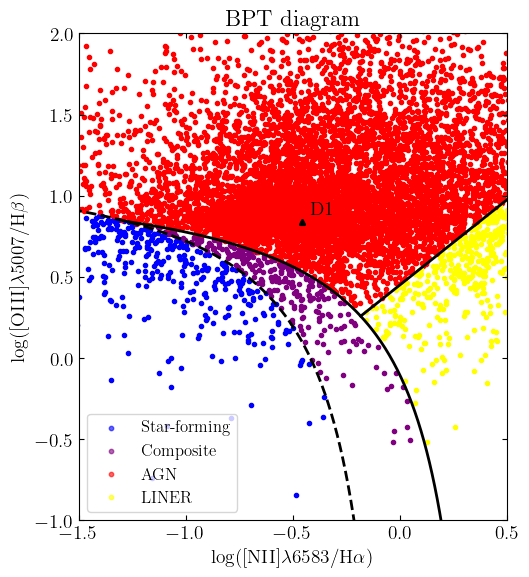

In [17]:
from astropy.io import fits
import numpy as np
import astropy.io.fits as fits
import orb
import orb.utils.graph as graph
import matplotlib.pyplot as plt
from orcs.process import SpectralCube
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import proj_plane_pixel_scales

map_ha = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')
map_ha[map_ha<0] = np.nan



map_hb = final
map_hb_err = err
map_hb[map_hb<0] = np.nan


map_nii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits')
map_nii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux-err.fits')
map_nii[map_nii<0] = np.nan



map_oiii = final1
map_oiii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.5007.1x1.flux-err.fits')
map_oiii[map_oiii<0] = np.nan


position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')

def classify_first_bpt(oiii_h_beta_ratio, nii_h_alpha_ratio):
        r"""
        Function for classification with BPT diagrams following
         Kewley et al. 2006 doi:10.1111/j.1365-2966.2006.10859.x using equation in Sect. 3.1
         and Schawinski et al. 2007 doi:10.1111/j.1365-2966.2007.12487.x Using equation 1 in Sect. 2.5.1
        :param oiii_h_beta_ratio: log-value of emission line ratio [OIII]5008 / H$\beta$4863
        :type oiii_h_beta_ratio: array-like
        :param nii_h_alpha_ratio: log-value of emission line ratio [NII]6550 / H$\alpha$6565
        :type nii_h_alpha_ratio: array-like
        :return variable specifying the BPT classification
        :rtype: str
        """

        if oiii_h_beta_ratio.ndim > 1:
            classification = np.zeros(oiii_h_beta_ratio.shape, dtype='S6')
        else:
            classification = np.zeros(len(oiii_h_beta_ratio), dtype='S6')

        # sf
        # eq. (1) (Kewley et al. 2006)
        mask_sf = (oiii_h_beta_ratio < 0.61 / (nii_h_alpha_ratio - 0.05) + 1.3) & (nii_h_alpha_ratio < - 0.1)
        classification[mask_sf] = 'sf'

        # composite
        # eq. (4) and (5) (Kewley et al. 2006)
        mask_comp = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) |
                      ((nii_h_alpha_ratio > - 0.1) & (nii_h_alpha_ratio < 0.4))) &
                     (oiii_h_beta_ratio < (0.61 / (nii_h_alpha_ratio - 0.47) + 1.19)))
        classification[mask_comp] = 'comp'

        # agn
        # eq. (6) (Kewley et al. 2006) with limit of nii_h_alpha_ratio < - 1.2825 and eq. (1) (Schawinski et al. 2007)
        mask_agn = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) & (nii_h_alpha_ratio < - 1.2825)) |
                    ((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) & (nii_h_alpha_ratio > - 1.2825)) |
                    ((oiii_h_beta_ratio > 1.05 * nii_h_alpha_ratio + 0.45) & (nii_h_alpha_ratio > - 0.05)))
        classification[mask_agn] = 'agn'

        # liner
        # eq. (11) (Kewley et al. 2006) and eq. (1) (Schawinski et al. 2007)
        mask_liner = (((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) &
                       (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)) |
                      ((nii_h_alpha_ratio > 0.45) & (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)))
        classification[mask_liner] = 'liner'

        return classification

def save_first_BPT_classification():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    # classification_first_bpt = np.zeros(map_ha.shape, dtype='S20')
    classification_first_bpt = classify_first_bpt(log_oiii_hb_map, log_nii_ha_map )
    # for i in range(hdr['NAXIS2']):
    #     for j in range(hdr['NAXIS1']):
    #         classification_first_bpt[i,j] = classify_first_bpt(log_oiii_hb_map[i,j], log_nii_ha_map [i,j])
    np.save('./classify_first_BPT_ID8_3arcsec.npy', classification_first_bpt)


def plot_BPT_diagram_2d_map_and_scatter_plot():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )



    fig = plt.figure(figsize=(10,6))



    ax = fig.add_subplot(122)


    ax.set_title(r'BPT diagram')
    tt_1 = np.arange(0.01, 1.0, 0.001)
    ax.plot(np.log10(tt_1), 0.61 / (np.log10(tt_1) - 0.05) + 1.3, 'k--', linewidth=2)

    tt_2 = np.arange(0.0521, 2.0, 0.01)
    ax.plot(np.log10(tt_2), 0.61 / (np.log10(tt_2) - 0.47) + 1.19, 'k-', linewidth=2)

    tt_3 = np.arange(0.655, 9.0, 0.01)
    ax.plot(np.log10(tt_3), 1.05 * np.log10(tt_3) + 0.45, 'k-', linewidth=2)

    ax.scatter(log_nii_ha_map[class_first_bpt==1.5], log_oiii_hb_map[class_first_bpt==1.5], marker='.', c='b')
    ax.scatter(log_nii_ha_map[class_first_bpt==2.5], log_oiii_hb_map[class_first_bpt==2.5], marker='.', c='purple')
    ax.scatter(log_nii_ha_map[class_first_bpt==3.5], log_oiii_hb_map[class_first_bpt==3.5], marker='.', c='r')
    ax.scatter(log_nii_ha_map[class_first_bpt==4.5], log_oiii_hb_map[class_first_bpt==4.5], marker='.', c='yellow')

    ax.set_xlabel(r'$\log([\mathrm{NII}]\lambda6583 / \mathrm{H}\alpha)$')
    ax.set_ylabel(r'$\log([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$')


    ax.scatter(
    log_nii_ha_map[class_first_bpt==1.5],
    log_oiii_hb_map[class_first_bpt==1.5],
    marker='.',
    c='b',
    s=10,
    alpha=0.6,
    label='Star-forming')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==2.5],
    log_oiii_hb_map[class_first_bpt==2.5],
    marker='.',
    c='purple',
    s=10,
    alpha=0.6,
    label='Composite')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==3.5],
    log_oiii_hb_map[class_first_bpt==3.5],
    marker='.',
    c='r',
    s=10,
    alpha=0.6,
    label='AGN')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==4.5],
    log_oiii_hb_map[class_first_bpt==4.5],
    marker='.',
    c='yellow',
    s=10,
    alpha=0.6,
    label='LINER')



    ax.legend(
    frameon=True,
    fontsize=12,
    markerscale=2)
    

    ax.set_xlim(-1.5, 0.5)
    ax.set_ylim(-1.0, 2.0)
    
    ax.scatter(
    log_nii_ha_ID8,
    log_oiii_hb_ID8,
    marker='^',
    s=10,
    color='black',
    linewidths=2,
    zorder=10
    )

    ax.annotate(
        'D1',
        (log_nii_ha_ID8, log_oiii_hb_ID8),
        xytext=(6, 6),
        textcoords='offset points'
    )

    plt.savefig(
    "/Users/leianydeoleo/Desktop/IIZW96/figures/IIZw96_bpt.png",
    dpi=300,
    bbox_inches="tight")
    
    



    #cb = plt.colorbar()
    
    plt.tight_layout()
    plt.show()



save_first_BPT_classification()

region_classification_first_BPT = np.load('./classify_first_BPT_ID8_3arcsec.npy')
class_first_bpt = np.zeros(region_classification_first_BPT.shape)
class_first_bpt[region_classification_first_BPT == b'sf'] = 1.5
class_first_bpt[region_classification_first_BPT == b'comp'] = 2.5
class_first_bpt[region_classification_first_BPT == b'agn'] = 3.5
class_first_bpt[region_classification_first_BPT == b'liner'] = 4.5

plot_BPT_diagram_2d_map_and_scatter_plot()

In [ ]:
 ax.scatter(
    log_nii_ha_ID8,
    log_oiii_hb_ID8,
    marker='^',
    s=10,
    color='black',
    linewidths=2,
    zorder=10
    )

    ax.annotate(
        'D1',
        (log_nii_ha_ID8, log_oiii_hb_ID8),
        xytext=(6, 6),
        textcoords='offset points'
    )

    ax.scatter(
    x, y,
    marker='^',
    s=10,
    color='black',
    linewidths=2,
    zorder=10
    )

    ax.annotate(
        'A',
        (x, y),
        xytext=(6, 6),
        textcoords='offset points'
    )
    
    
    ax.scatter(
    log_nii_ha_ID11,
    log_oiii_hb_ID11,
    marker='^',
    s=10,
    color='black',
    linewidths=2,
    zorder=10
    )
    
    ax.annotate(
        'C0',
        (log_nii_ha_ID11, log_oiii_hb_ID11),
        xytext=(6, 6),
        textcoords='offset points'
    )


    

unknown|WARNING| posx and posy should be finite values
unknown|WARNING| posx and posy should be finite values


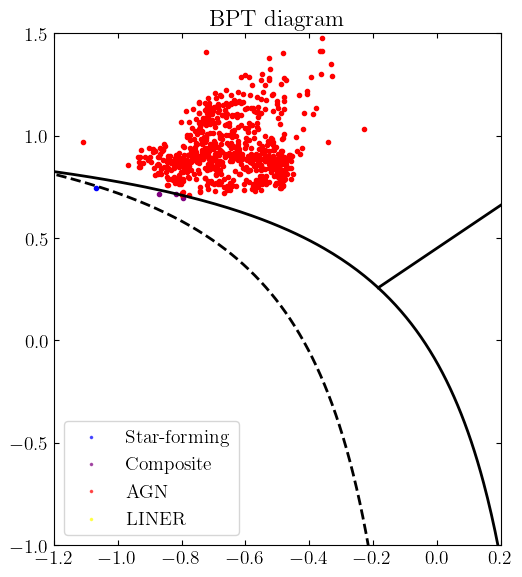

In [212]:
from astropy.io import fits
import numpy as np
import astropy.io.fits as fits
import orb
import orb.utils.graph as graph
import matplotlib.pyplot as plt
from orcs.process import SpectralCube
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import skycoord_to_pixel

map_ha = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')
ha_line_snr = map_ha / map_ha_err
#valid_mask = (ha_line_snr > 3) & np.isfinite(map_ha)
#map_ha[~valid_mask] = np.nan
map_ha[map_ha<0] = np.nan
map_ha[ha_line_snr<=3] = np.nan

flux = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits') 
err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')
map_hb = final
map_hb_err = err



map_nii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits')
map_nii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux-err.fits')
map_nii[map_nii<0] = np.nan
nii_line_snr = map_nii / map_nii_err
map_nii[nii_line_snr<=3] = np.nan


map_oiii = final1
map_oiii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.5007.1x1.flux-err.fits')





position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')

def classify_first_bpt(oiii_h_beta_ratio, nii_h_alpha_ratio):
        r"""
        Function for classification with BPT diagrams following
         Kewley et al. 2006 doi:10.1111/j.1365-2966.2006.10859.x using equation in Sect. 3.1
         and Schawinski et al. 2007 doi:10.1111/j.1365-2966.2007.12487.x Using equation 1 in Sect. 2.5.1
        :param oiii_h_beta_ratio: log-value of emission line ratio [OIII]5008 / H$\beta$4863
        :type oiii_h_beta_ratio: array-like
        :param nii_h_alpha_ratio: log-value of emission line ratio [NII]6550 / H$\alpha$6565
        :type nii_h_alpha_ratio: array-like
        :return variable specifying the BPT classification
        :rtype: str
        """

        if oiii_h_beta_ratio.ndim > 1:
            classification = np.zeros(oiii_h_beta_ratio.shape, dtype='S6')
        else:
            classification = np.zeros(len(oiii_h_beta_ratio), dtype='S6')

        # sf
        # eq. (1) (Kewley et al. 2006)
        mask_sf = (oiii_h_beta_ratio < 0.61 / (nii_h_alpha_ratio - 0.05) + 1.3) & (nii_h_alpha_ratio < - 0.1)
        classification[mask_sf] = 'sf'

        # composite
        # eq. (4) and (5) (Kewley et al. 2006)
        mask_comp = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) |
                      ((nii_h_alpha_ratio > - 0.1) & (nii_h_alpha_ratio < 0.4))) &
                     (oiii_h_beta_ratio < (0.61 / (nii_h_alpha_ratio - 0.47) + 1.19)))
        classification[mask_comp] = 'comp'

        # agn
        # eq. (6) (Kewley et al. 2006) with limit of nii_h_alpha_ratio < - 1.2825 and eq. (1) (Schawinski et al. 2007)
        mask_agn = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) & (nii_h_alpha_ratio < - 1.2825)) |
                    ((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) & (nii_h_alpha_ratio > - 1.2825)) |
                    ((oiii_h_beta_ratio > 1.05 * nii_h_alpha_ratio + 0.45) & (nii_h_alpha_ratio > - 0.05)))
        classification[mask_agn] = 'agn'

        # liner
        # eq. (11) (Kewley et al. 2006) and eq. (1) (Schawinski et al. 2007)
        mask_liner = (((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) &
                       (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)) |
                      ((nii_h_alpha_ratio > 0.45) & (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)))
        classification[mask_liner] = 'liner'

        return classification

def save_first_BPT_classification():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    # classification_first_bpt = np.zeros(map_ha.shape, dtype='S20')
    classification_first_bpt = classify_first_bpt(log_oiii_hb_map, log_nii_ha_map )
    # for i in range(hdr['NAXIS2']):
    #     for j in range(hdr['NAXIS1']):
    #         classification_first_bpt[i,j] = classify_first_bpt(log_oiii_hb_map[i,j], log_nii_ha_map [i,j])
    np.save('./classify_first_BPT_ID8_3arcsec.npy', classification_first_bpt)


def plot_BPT_diagram_2d_map_and_scatter_plot():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )



    fig = plt.figure(figsize=(10,6))



    ax = fig.add_subplot(122)
    ax.scatter(x_bpt, y_bpt, marker='x', s=120, color='black')
    ax.annotate('ID8', (x_bpt, y_bpt), xytext=(6, 6), textcoords='offset points', color='m')

    ax.set_title(r'BPT diagram')
    tt_1 = np.arange(0.01, 1.0, 0.001)
    ax.plot(np.log10(tt_1), 0.61 / (np.log10(tt_1) - 0.05) + 1.3, 'k--', linewidth=2)

    tt_2 = np.arange(0.0521, 2.0, 0.01)
    ax.plot(np.log10(tt_2), 0.61 / (np.log10(tt_2) - 0.47) + 1.19, 'k-', linewidth=2)

    tt_3 = np.arange(0.655, 9.0, 0.01)
    ax.plot(np.log10(tt_3), 1.05 * np.log10(tt_3) + 0.45, 'k-', linewidth=2)

    ax.scatter(log_nii_ha_map[class_first_bpt==1.5], log_oiii_hb_map[class_first_bpt==1.5], marker='.', c='b')
    ax.scatter(log_nii_ha_map[class_first_bpt==2.5], log_oiii_hb_map[class_first_bpt==2.5], marker='.', c='purple')
    ax.scatter(log_nii_ha_map[class_first_bpt==3.5], log_oiii_hb_map[class_first_bpt==3.5], marker='.', c='r')
    ax.scatter(log_nii_ha_map[class_first_bpt==4.5], log_oiii_hb_map[class_first_bpt==4.5], marker='.', c='yellow')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==1.5],
    log_oiii_hb_map[class_first_bpt==1.5],
    marker='.',
    c='b',
    s=10,
    alpha=0.6,
    label='Star-forming')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==2.5],
    log_oiii_hb_map[class_first_bpt==2.5],
    marker='.',
    c='purple',
    s=10,
    alpha=0.6,
    label='Composite')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==3.5],
    log_oiii_hb_map[class_first_bpt==3.5],
    marker='.',
    c='r',
    s=10,
    alpha=0.6,
    label='AGN')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==4.5],
    log_oiii_hb_map[class_first_bpt==4.5],
    marker='.',
    c='yellow',
    s=10,
    alpha=0.6,
    label='LINER')

    ax.legend( loc='upper right',
    frameon=True,
    fontsize=12,
    markerscale=2)
    #ax.set_xlim(np.log10(0.3), np.log10(1.9))
    #ax.set_ylim(np.log10(0.07), np.log10(9))

    ax.set_xlim(-1.2, 0.2)
    ax.set_ylim(-1.0, 1.5)
    ax.legend()


    #cb = plt.colorbar()
    xpixC, ypixC = position_ID8.to_pixel(wcs)
    
    xpixC = int(np.asarray(xpixC).ravel()[0])
    ypixC = int(np.asarray(ypixC).ravel()[0])
    
    x_ID8 = log_nii_ha_map[ypixC, xpixC]
    y_ID8 = log_oiii_hb_map[ypixC, xpixC]

    ax.scatter(
    x_ID8,
    y_ID8,
    marker='.',
    facecolors='none',
    edgecolors='yellow',
    s=10,
    linewidths=1.5
    )
    
    ax.text(
        x_ID8,
        y_ID8,
        'D1',
        color='black',
        fontsize=9,
        ha='center',
        va='bottom'
    )
        



    plt.tight_layout()
    plt.show()




save_first_BPT_classification()

region_classification_first_BPT = np.load('./classify_first_BPT_ID8_3arcsec.npy')
class_first_bpt = np.zeros(region_classification_first_BPT.shape)
class_first_bpt[region_classification_first_BPT == b'sf'] = 1.5
class_first_bpt[region_classification_first_BPT == b'comp'] = 2.5
class_first_bpt[region_classification_first_BPT == b'agn'] = 3.5
class_first_bpt[region_classification_first_BPT == b'liner'] = 4.5

plot_BPT_diagram_2d_map_and_scatter_plot()

<Figure size 640x480 with 0 Axes>

unknown|WARNING| posx and posy should be finite values
unknown|WARNING| posx and posy should be finite values


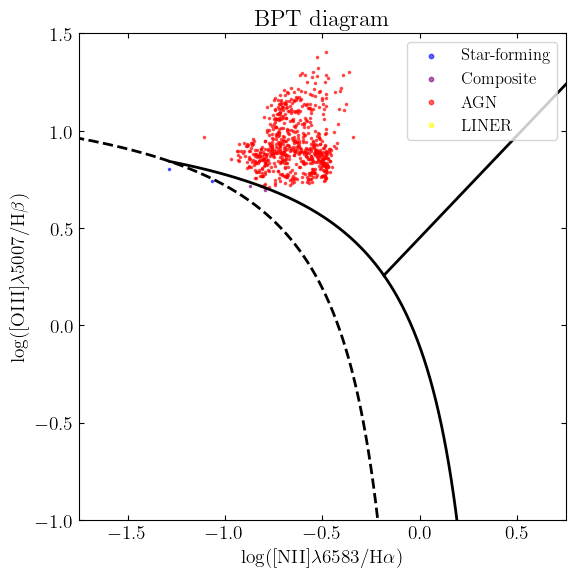

In [182]:
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion
from matplotlib.patches import Rectangle


def classify_first_bpt(oiii_h_beta_ratio, nii_h_alpha_ratio):
        r"""
        Function for classification with BPT diagrams following
         Kewley et al. 2006 doi:10.1111/j.1365-2966.2006.10859.x using equation in Sect. 3.1
         and Schawinski et al. 2007 doi:10.1111/j.1365-2966.2007.12487.x Using equation 1 in Sect. 2.5.1
        :param oiii_h_beta_ratio: log-value of emission line ratio [OIII]5008 / H$\beta$4863
        :type oiii_h_beta_ratio: array-like
        :param nii_h_alpha_ratio: log-value of emission line ratio [NII]6550 / H$\alpha$6565
        :type nii_h_alpha_ratio: array-like
        :return variable specifying the BPT classification
        :rtype: str
        """

        if oiii_h_beta_ratio.ndim > 1:
            classification = np.zeros(oiii_h_beta_ratio.shape, dtype='S6')
        else:
            classification = np.zeros(len(oiii_h_beta_ratio), dtype='S6')

        # sf
        # eq. (1) (Kewley et al. 2006)
        mask_sf = (oiii_h_beta_ratio < 0.61 / (nii_h_alpha_ratio - 0.05) + 1.3) & (nii_h_alpha_ratio < - 0.1)
        classification[mask_sf] = 'sf'

        # composite
        # eq. (4) and (5) (Kewley et al. 2006)
        mask_comp = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) |
                      ((nii_h_alpha_ratio > - 0.1) & (nii_h_alpha_ratio < 0.4))) &
                     (oiii_h_beta_ratio < (0.61 / (nii_h_alpha_ratio - 0.47) + 1.19)))
        classification[mask_comp] = 'comp'

        # agn
        # eq. (6) (Kewley et al. 2006) with limit of nii_h_alpha_ratio < - 1.2825 and eq. (1) (Schawinski et al. 2007)
        mask_agn = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) & (nii_h_alpha_ratio < - 1.2825)) |
                    ((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) & (nii_h_alpha_ratio > - 1.2825)) |
                    ((oiii_h_beta_ratio > 1.05 * nii_h_alpha_ratio + 0.45) & (nii_h_alpha_ratio > - 0.05)))
        classification[mask_agn] = 'agn'

        # liner
        # eq. (11) (Kewley et al. 2006) and eq. (1) (Schawinski et al. 2007)
        mask_liner = (((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) &
                       (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)) |
                      ((nii_h_alpha_ratio > 0.45) & (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)))
        classification[mask_liner] = 'liner'

        return classification

def save_first_BPT_classification():
    hdr = map_ha_hdr
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    classification_first_bpt = np.zeros(map_ha.shape, dtype='S20')
    classification_first_bpt = classify_first_bpt(log_oiii_hb_map, log_nii_ha_map )
    #for i in range(hdr['NAXIS2']):
    #for j in range(hdr['NAXIS1']):
     #        classification_first_bpt[i,j] = classify_first_bpt(log_oiii_hb_map[i,j], log_nii_ha_map [i,j])
     #        np.save('./classify_first_BPT_ID8_3arcsec.npy', classification_first_bpt)


def plot_BPT_diagram_2d_map_and_scatter_plot():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    hdr = map_ha_hdr
    wcs = WCS(hdr)

    fig = plt.figure()

    #ax1 = fig.add_subplot( projection=cube_SN3.get_wcs())
    fig = plt.figure(figsize=(6, 6), dpi=100)






    cmap = colors.ListedColormap(['purple', 'green', 'orange', 'yellow'])
    bounds = [1, 2, 3, 4, 5]
    norm = colors.BoundaryNorm(bounds, cmap.N)




    ax2 = fig.add_subplot(111)

    ax2.set_title(r'BPT diagram')
    tt_1 = np.arange(0.01, 1.0, 0.001)
    ax2.plot(np.log10(tt_1), 0.61 / (np.log10(tt_1) - 0.05) + 1.3, 'k--', linewidth=2)

    tt_2 = np.arange(0.0521, 2.0, 0.01)
    ax2.plot(np.log10(tt_2), 0.61 / (np.log10(tt_2) - 0.47) + 1.19, 'k-', linewidth=2)

    tt_3 = np.arange(0.655, 9.0, 0.01)
    ax2.plot(np.log10(tt_3), 1.05 * np.log10(tt_3) + 0.45, 'k-', linewidth=2)

    ax2.set_aspect('equal', adjustable='box')
    ax2.set_box_aspect(1)



    ax2.set_xlabel(r'$\log([\mathrm{NII}]\lambda6583 / \mathrm{H}\alpha)$')
    ax2.set_ylabel(r'$\log([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$')


    ax2.scatter(
    log_nii_ha_map[class_first_bpt==1.5],
    log_oiii_hb_map[class_first_bpt==1.5],
    marker='.',
    c='b',
    s=10,
    alpha=0.6,
    label='Star-forming')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==2.5],
    log_oiii_hb_map[class_first_bpt==2.5],
    marker='.',
    c='purple',
    s=10,
    alpha=0.6,
    label='Composite')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==3.5],
    log_oiii_hb_map[class_first_bpt==3.5],
    marker='.',
    c='r',
    s=10,
    alpha=0.6,
    label='AGN')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==4.5],
    log_oiii_hb_map[class_first_bpt==4.5],
    marker='.',
    c='yellow',
    s=10,
    alpha=0.6,
    label='LINER')

    ax2.legend( loc='upper right',
    frameon=True,
    fontsize=12,
    markerscale=2)
    ax2.set_xlim(-1.2, 0.2)
    ax2.set_ylim(-1.0, 1.5)

    xpixC, ypixC = position_ID8.to_pixel(wcs)
    
    xpixC = int(np.asarray(xpixC).ravel()[0])
    ypixC = int(np.asarray(ypixC).ravel()[0])
    
    x_ID8 = log_nii_ha_map[ypixC, xpixC]
    y_ID8 = log_oiii_hb_map[ypixC, xpixC]

    ax2.scatter(
    x_ID8,
    y_ID8,
    marker='s',
    facecolors='none',
    edgecolors='black',
    s=100,
    linewidths=1.5
    )
    
    ax2.text(
        x_ID8,
        y_ID8,
        'D1',
        color='black',
        fontsize=9,
        ha='center',
        va='bottom'
    )
        
    
  



    plt.tight_layout()
    plt.show()

 

region_classification_first_BPT = np.load('./classify_first_BPT_ID8_3arcsec.npy')
class_first_bpt = np.zeros(region_classification_first_BPT.shape)
class_first_bpt[region_classification_first_BPT == b'sf'] = 1.5
class_first_bpt[region_classification_first_BPT == b'comp'] = 2.5
class_first_bpt[region_classification_first_BPT == b'agn'] = 3.5
class_first_bpt[region_classification_first_BPT == b'liner'] = 4.5

plot_BPT_diagram_2d_map_and_scatter_plot()